# 03 Pricing a European option

The Monte Carlo price is just the average discounted payoff:

$$\hat{P} = e^{-rT} \cdot \frac{1}{M} \sum_{i=1}^{M} \max(S_T^i - K,\ 0)$$

To verify correctness, we compare this estimate to the Black-Scholes closed-form price:
$$\text{For call prices: } C = S_0 N(d_1) - K e^{-rT} N(d_2)$$
$$\text{For put prices: } P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$
$$\text{where }d_1 =
\frac{\ln\left(\frac{S_0}{K}\right) + \left(r + \tfrac{1}{2}\sigma^2\right)T}
{\sigma\sqrt{T}}, d_2 = d_1 - \sigma\sqrt{T}$$

We then show how the estimate converges as M grows.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from pricer import mc_pricing, bs_pricing

## parameters

In [2]:
Sof0        = 100
K           = 105     # strike price — slightly out of the money
r           = 0.05    # risk-free rate (5%)
sigma       = 0.20    # volatility (20%)
T           = 1.0     # one year
N           = int(252 * T)    # 1 step per day, changes with T
M           = 10000   # number of paths

## Monte Carlo vs. Black-Scholes

In [3]:
mc_price = mc_pricing(Sof0, K, r, sigma, T, N, M, option_type='call', seed=42)
bs_price = bs_pricing(Sof0, K, r, sigma, T, option_type='call')

print(f"Monte Carlo price : ${mc_price:.4f}")
print(f"Black-Scholes price: ${bs_price:.4f}")
print(f"Difference        : ${abs(mc_price - bs_price):.4f}")

Monte Carlo price : $8.0623
Black-Scholes price: $8.0214
Difference        : $0.0409


## convergence

By the law of large numbers: as we increase the number of simulations $M$, the Monte Carlo estimate converges to the true Black-Scholes price.


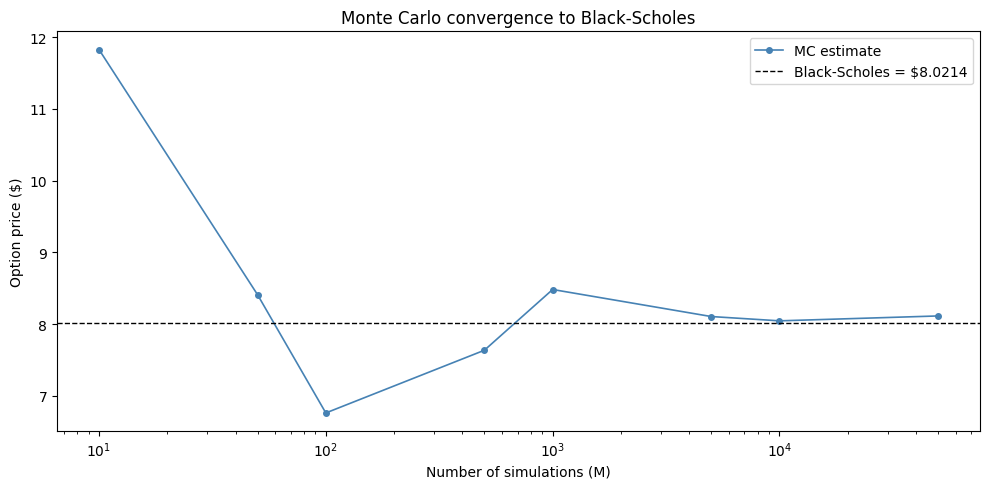

In [4]:
M_values = [10, 50, 100, 500, 1000, 5000, 10000, 50000]
mc_prices = [mc_pricing(Sof0, K, r, sigma, T, N, M_val, seed=42) for M_val in M_values]

plt.figure(figsize=(10, 5))
plt.plot(M_values, mc_prices, color='steelblue', linewidth=1.2, marker='o', markersize=4, label='MC estimate')
plt.axhline(bs_price, color='black', linestyle='--', linewidth=1.0, label=f'Black-Scholes = ${bs_price:.4f}')
plt.xscale('log')
plt.xlabel('Number of simulations (M)')
plt.ylabel('Option price ($)')
plt.title('Monte Carlo convergence to Black-Scholes')
plt.legend()
plt.tight_layout()
plt.show()

## payoff histogram

Shows the distribution of payoffs across all paths. There will be a spike at zero which represents paths which resulted in worthless expiries, where the stock finished just below the strike price.

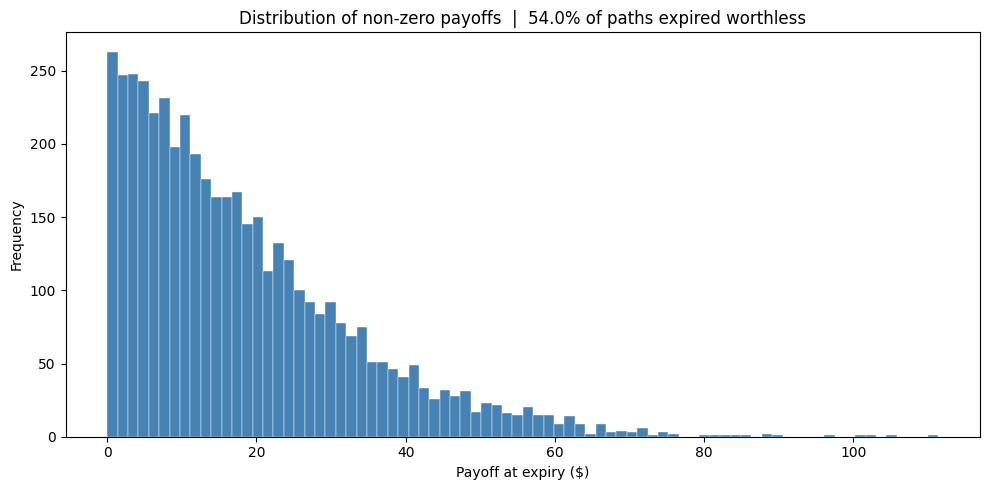

In [5]:
from gbm import simulate_paths

paths       = simulate_paths(Sof0, r, sigma, T, N, M, seed=42)
final       = paths[-1, :]
payoffs     = np.maximum(final - K, 0)
pct_worthless = (payoffs == 0).mean() * 100

plt.figure(figsize=(10, 5))
plt.hist(payoffs[payoffs > 0], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
plt.xlabel('Payoff at expiry ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of non-zero payoffs  |  {pct_worthless:.1f}% of paths expired worthless')
plt.tight_layout()
plt.show()